# 0.1 Pass by usando medidas de aforadores automáticos
A continuación se tratará de extraer el pass by usando los datos de un sonómetro en continuo que
esta en simultaneo con una estación aforadora. El objetivo es relacionar la información de niveles
de ruido cada segundo con las detecciones de pasos y velocidades que entrega la estación aforadora

In [11]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import plotly.express as px
#plt.style.use("bmh")
%matplotlib inline

In [12]:
def leq(levels:np.ndarray)->float:
    levels = levels[~np.isnan(levels)]
    l = np.array(levels)
    return 10*np.log10(np.mean(np.power(10,l/10)))

# 0.2 Lectura de datos de la estación aforadora
El rada entrega información de dirección de circulación, velocidad y tipo de vehiculo según longitud
entre las siguientes clases:
* 1:bicis y motos
* 2:turismos
* 3:camión
* 4:camión largo

In [13]:
# df = pd.read_csv("20230203.CSV", sep=";")
file_path = r"\\192.168.205.117\AAC_Server\TRAFICO\REGISTRO_RADAR_VITORIA_2023\P2_M_GANDHI\20230615.CSV"
df = pd.read_csv(file_path, sep=";")
df.head()

,Date,Time,Type,Direction,Speed
0,15/06/23,00:01:09,Type 2,In,48
1,15/06/23,00:08:55,Type 2,Out,37
2,15/06/23,00:15:02,Type 2,Out,51
3,15/06/23,00:16:46,Type 2,In,52
4,15/06/23,00:20:40,Type 2,Out,52


el 95% de las detecciones son de vehiculos tipo turismo, y 3% para camiones

In [14]:
df["datetime"] = pd.to_datetime(df["Date"] + " " + df["Time"], format="%d/%m/%y %H:%M:%S")
# Delay con respecto a sonómetro
df["datetime"] = df["datetime"] + pd.Timedelta("25S")
df

,Date,Time,Type,Direction,Speed,datetime
0,15/06/23,00:01:09,Type 2,In,48,2023-06-15 00:01:34
1,15/06/23,00:08:55,Type 2,Out,37,2023-06-15 00:09:20
2,15/06/23,00:15:02,Type 2,Out,51,2023-06-15 00:15:27
3,15/06/23,00:16:46,Type 2,In,52,2023-06-15 00:17:11
4,15/06/23,00:20:40,Type 2,Out,52,2023-06-15 00:21:05
...,...,...,...,...,...,...
3976,15/06/23,23:53:36,Type 2,In,44,2023-06-15 23:54:01
3977,15/06/23,23:53:49,Type 2,In,55,2023-06-15 23:54:14
3978,15/06/23,23:54:15,Type 2,In,48,2023-06-15 23:54:40
3979,15/06/23,23:58:26,Type 1,In,64,2023-06-15 23:58:51


In [15]:
df["Type"].value_counts(normalize=True)

Type 2    0.939714
Type 1    0.053755
Type 3    0.006029
Type 4    0.000502
Name: Type, dtype: float64

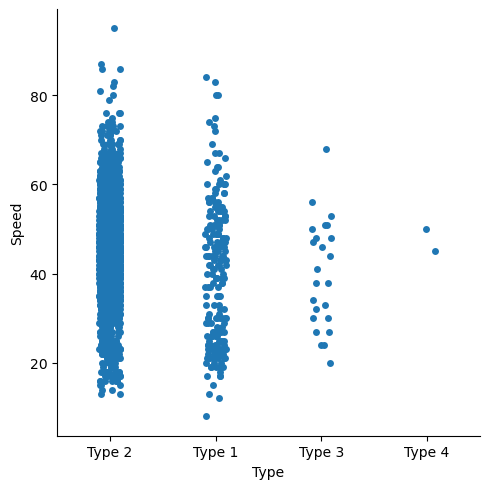

In [16]:
sns.catplot(data=df, x="Type",y="Speed");

#  1 LECTURA DE DATOS NIVELES DE RUIDO

In [17]:
# df_noise = pd.read_csv("Audiomoth2_Tanis_Aguirrebengoa_20230203_spl.csv",parse_dates=["date"])
df_noise = pd.read_csv("Audiomoth2_Tanis_Aguirrebengoa_20230615_spl.csv", parse_dates=["date"])
noise_file_path = ""
df_noise["date"] = df_noise["date"] + pd.Timedelta("1H")

FileNotFoundError: [Errno 2] No such file or directory: 'Audiomoth2_Tanis_Aguirrebengoa_20230203_spl.csv'

Inicilamente se usa el campo que contiene la información de los timestamps de las detecciónes para
unir los datos de la estación de aforos con los niveles de ruido. Como la longitud de los datos
de ruido no es igual a la de los datos de los aforos, se realiza una union “izquierda” en donde se
conservan los datos de la tabla izquierda(ruido) y solo se unen los datos de aforo en los campos
coincidentes.

In [ ]:
df_join = pd.merge(df_noise,df,left_on="date", right_on="datetime",how="left")

Se puede observar en el siguiente gráfico como la detecciones del sistema de aforos concuerdan con
los picos de niveles de ruido en este segmento.

In [ ]:
df_join = df_join.set_index("date")
df_temp = df_join.loc["2023-02-03 23:55:00":"2023-02-03 23:58:00"]
levels = df_temp["LA"].values
speed = df_temp["Speed"].values
plt.figure(figsize=(15,6))
plt.plot(df_temp.index, levels);
plt.plot(df_temp.index,speed+40,"*");

# 1.1 Selección de pass bys
Se seleccionan aquellas detecciones que tiene un espacio mayor a 10 segundos con la detección
anteior y la siguiente

In [ ]:
df_car_detections = df_join[~df_join["Speed"].isna()].copy()
df_car_detections["left"] = df_car_detections["datetime"].shift()
df_car_detections["right"] = df_car_detections["datetime"].shift(-1)
df_car_detections["diff_left"] = df_car_detections["datetime"] - df_car_detections["left"]
df_car_detections["diff_right"] = df_car_detections["right"] - df_car_detections["datetime"]

# Select clean pass bys
df_clean_pass_by = df_car_detections[ (df_car_detections["diff_left"] > "10s") & (df_car_detections["diff_right"] > "10s") ].copy()

Usando estas detecciones se calcula el nivel exposición sonora con los datos de ruido y se grafican
los niveles para comprpbar que corresponden con las formas de onda tipicas de pass by. Se puede
observar que la mayoria siguen en este patrón aunque existen otras tantas que difieren del patrón
tipico de pass-by

In [ ]:
pass_by_width_seconds = 10
sel_pass = []
i = 0
plt.figure(figsize=(15,8))
for date_paso, pass_by in df_clean_pass_by.iterrows():

    df_temp = df_join.loc[date_paso - pd.Timedelta(f"{pass_by_width_seconds}s"):
    date_paso + pd.Timedelta(f"{pass_by_width_seconds}s") ]
    levels = df_temp["LA"]
    sel_pass.append(leq(levels) + np.log(8))
    plt.plot(levels.values, linewidth=0.15)
    #i+=1
    if i == 5:
        break

plt.xlabel("seconds")
plt.ylabel("LAeq1s")
plt.show()
df_clean_pass_by["SEL"] = sel_pass

Finalmente se puede observar la relación entre velocidad y SEL de los datos recogidos con el pass
by automático

In [ ]:
sns.jointplot(data=df_clean_pass_by, x="Speed", y = "SEL",);